# Evaluation, Grad-CAM, and Error Analysis

A high accuracy score on a balanced binary task is a weak result on its own. It cannot
distinguish a model that recognizes animals from one that has latched onto a spurious
correlation (indoor-vs-outdoor backgrounds, say, or the presence of a collar), and it
says nothing about which images remain hard.

This notebook attacks both questions:

* **Per-class precision, recall, and F1**, plus a confusion matrix, to see whether errors are symmetric or the model systematically favors one class.
* **Grad-CAM**, to visualize which image regions actually drive each prediction. This is the single most informative addition here: it is the difference between reporting that a model works and showing *why* it works.
* **Error analysis on the most confidently wrong predictions**, which is where mislabeled and genuinely ambiguous images surface.

Everything below uses the best checkpoint from notebook 02 and the held-out **test**
split from notebook 01, which is the one set of images that has been touched by
neither training nor checkpoint selection. Notebook 02 chose its checkpoint by
validation loss, so the validation score is a maximum taken over every epoch and is
biased upward. The numbers below are not.

## Imports and setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from catsdogs.dataset import IMAGENET_MEAN, IMAGENET_STD, CatsDogsDataset, build_transforms
from catsdogs.evaluate import (
    compute_confusion_matrix,
    most_confident_errors,
    per_class_metrics,
    predict_probabilities,
)
from catsdogs.gradcam import GradCAM, overlay_heatmap
from catsdogs.model import build_model

CLASS_NAMES = ["cat", "dog"]
PROCESSED_DIR = Path("../data/processed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The model is rebuilt with `pretrained=False` before loading the checkpoint, since there
is no sense downloading ImageNet weights only to immediately overwrite them with our
fine-tuned ones. The evaluation transform is deterministic, which matters here: Grad-CAM
and the error analysis both need the *same* image every time they index into the
dataset.

In [3]:
model = build_model(num_classes=2, pretrained=False)
model.load_state_dict(torch.load("../outputs/checkpoints/best.pt", map_location=device))
model.to(device)

test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")
test_paths = [Path(p) for p in test_df["path"]]
test_labels = np.array(test_df["label"])

test_dataset = CatsDogsDataset(test_paths, list(test_labels), build_transforms(train=False))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"evaluating on {len(test_dataset)} held-out images")

evaluating on 3744 held-out images


## Metrics

`predict_probabilities` returns softmax outputs rather than hard labels. Keeping the
probabilities is what makes the error analysis at the end possible: ranking mistakes by
confidence requires knowing how confident the model was, which `argmax` discards.

On a balanced dataset, accuracy, macro precision, and macro recall will be close
together. The per-class breakdown is the informative part: a precision/recall imbalance
*within* a class means the model has an asymmetric bias, mistaking one class for the
other more readily than the reverse.

In [4]:
probs = predict_probabilities(model, test_loader, device)
preds = probs.argmax(axis=1)

accuracy = (preds == test_labels).mean()
print(f"accuracy: {accuracy:.4f}")

pd.DataFrame(per_class_metrics(test_labels, preds), index=CLASS_NAMES).round(4)

accuracy: 0.9882


,precision,recall,f1
cat,0.9893,0.9872,0.9882
dog,0.9872,0.9893,0.9883


## Confusion matrix

With only two classes the confusion matrix holds four numbers, but it answers a question
the metrics table does not pose directly: are the off-diagonal counts balanced?

Roughly equal off-diagonals mean the model is simply wrong occasionally. A lopsided
matrix, with many more cats called dogs than the reverse, points to a systematic bias,
and since notebook 01 confirmed the classes are balanced and the split was stratified,
such a bias could not be blamed on the data distribution.

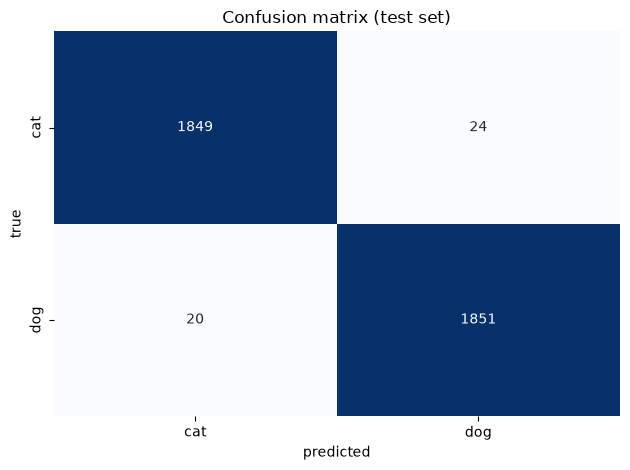

cats misread as dogs: 24
dogs misread as cats: 20


In [5]:
cm = compute_confusion_matrix(test_labels, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False,
)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

print(f"cats misread as dogs: {cm[0, 1]}")
print(f"dogs misread as cats: {cm[1, 0]}")

## Grad-CAM: what is the model looking at?

Grad-CAM (Gradient-weighted Class Activation Mapping) answers a question metrics cannot:
*which pixels mattered?*

The mechanism is short enough to state precisely. Take the score for the predicted class
and backpropagate it to the final convolutional block's activation maps. Average each
channel's gradient spatially. That average is how much the class score would change if
that channel were more active, so it serves as the channel's importance weight. Sum the
activation maps weighted by those importances, discard negative contributions with a
ReLU, and upsample the result to the input size. Regions that survive are the regions
that pushed the prediction toward the chosen class.

`src/catsdogs/gradcam.py` implements this directly with forward and backward hooks
rather than pulling in a Grad-CAM library. For a case study the implementation *is* part
of the demonstration, and it keeps the dependency list short.

One honest caveat about resolution: `layer4` outputs a 7x7 spatial grid for a 224x224
input, so each heatmap cell covers a 32x32 pixel region. These maps localize to "the
animal's head" but never to fine detail, and the smooth blobs are an artifact of
bilinear upsampling, not evidence of smooth attention. Reading them as precise pixel
attributions would be overinterpreting.

In [6]:
cam = GradCAM(model, model.layer4[-1])


def to_display_image(tensor: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalization so a tensor can be shown as an image."""
    array = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(array * IMAGENET_STD + IMAGENET_MEAN, 0, 1)


def label_text(idx: int) -> str:
    return (
        f"true={CLASS_NAMES[test_labels[idx]]}, "
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.2f})"
    )

Correct predictions first, as a baseline for what healthy attention looks like. Expect
the heat to concentrate on the animal, typically the face, rather than on background. If
it consistently landed on furniture, grass, or image borders, high accuracy would be a
warning sign rather than a success: the model would be exploiting dataset artifacts that
will not survive contact with new photographs.

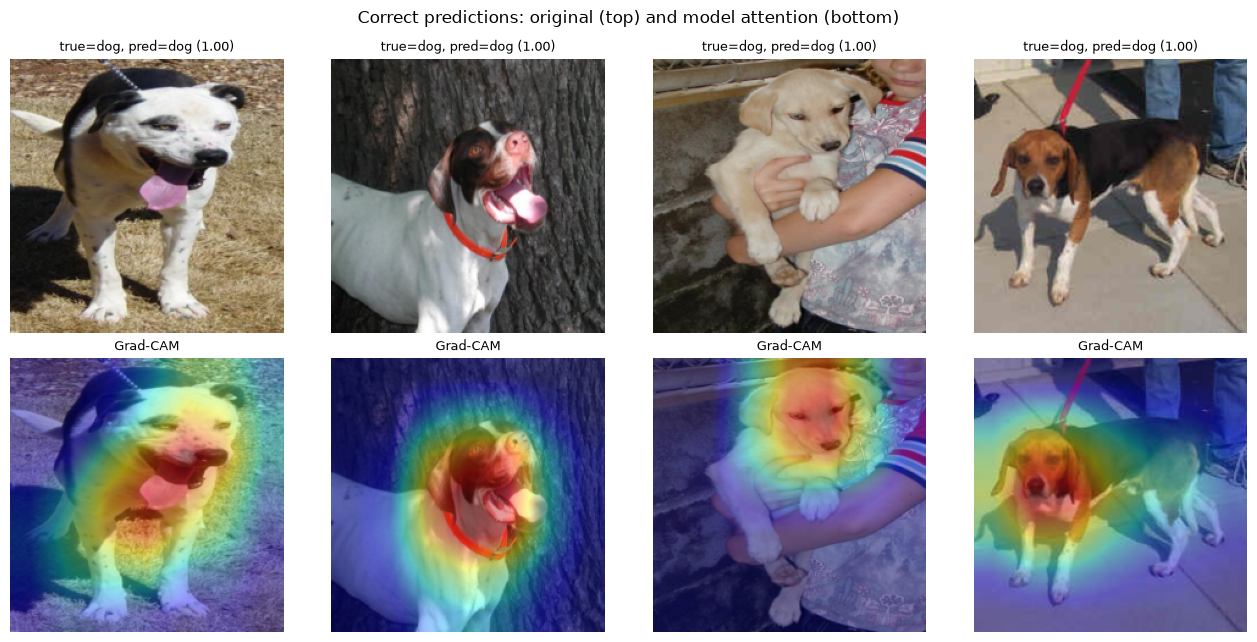

In [7]:
correct_idx = np.flatnonzero(preds == test_labels)[:4]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for col, idx in enumerate(correct_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Correct predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_correct.png", dpi=150)
plt.show()

Now the same treatment for mistakes. These are the more interesting maps, because they
separate two very different kinds of failure: the model looked at the right subject and
still misjudged it, or it looked somewhere unhelpful entirely. Only the second is really
an attention problem, and the distinction is invisible to any metric.

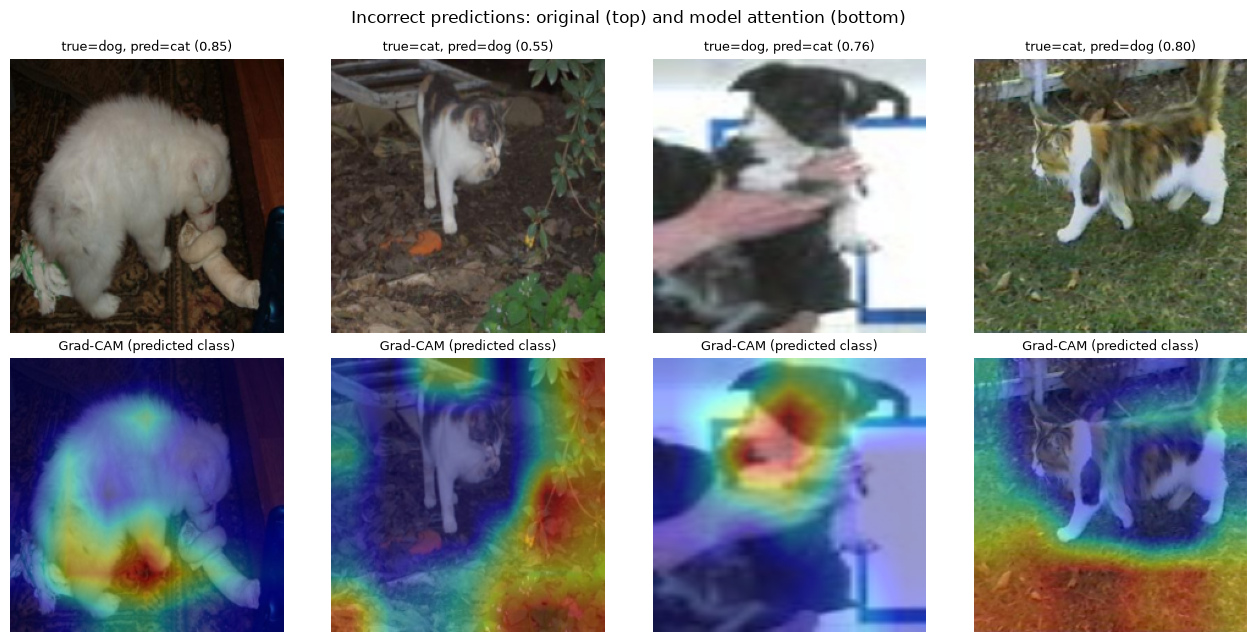

In [8]:
wrong_idx = np.flatnonzero(preds != test_labels)[:4]

fig, axes = plt.subplots(2, len(wrong_idx), figsize=(13, 6.5))
for col, idx in enumerate(wrong_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM (predicted class)", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Incorrect predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_incorrect.png", dpi=150)
plt.show()

## Error analysis: the most confidently wrong predictions

Not all mistakes are equally informative. An image the model called a dog with 51%
confidence is a coin flip near the decision boundary and tells us little. An image it
called a dog with 99% confidence *and got wrong* is a real failure of the learned
representation, or a mislabeled file.

`most_confident_errors` ranks misclassified examples by the probability assigned to
the wrong class, surfacing the worst cases first. This is the cell to read closely,
because a web-scraped dataset of this kind tends to hide a few pathological images
in the tail: frames containing both a cat and a dog, animals barely visible in the
shot, and occasionally files that are not animal photographs at all. Whether any of
those actually appear here is exactly what the figure below settles.

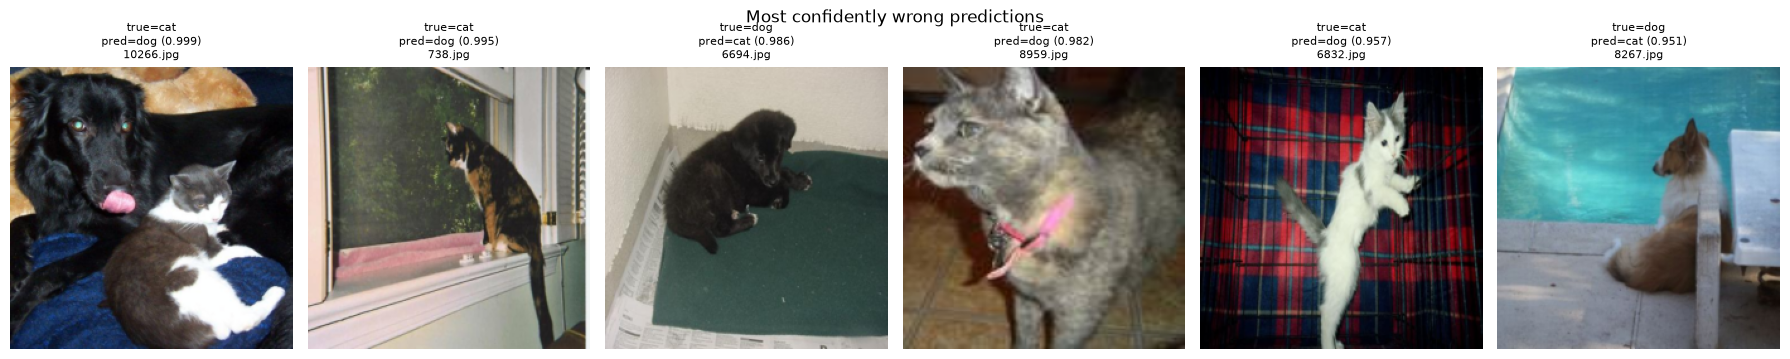

,file,true,predicted,confidence
0,10266.jpg,cat,dog,0.999048
1,738.jpg,cat,dog,0.995372
2,6694.jpg,dog,cat,0.986277
3,8959.jpg,cat,dog,0.982247
4,6832.jpg,cat,dog,0.957136
5,8267.jpg,dog,cat,0.950611


In [9]:
worst_idx = most_confident_errors(test_labels, probs, k=6)

fig, axes = plt.subplots(1, len(worst_idx), figsize=(3 * len(worst_idx), 3.8))
for col, idx in enumerate(worst_idx):
    axes[col].imshow(to_display_image(test_dataset[idx][0].unsqueeze(0)))
    axes[col].set_title(
        f"true={CLASS_NAMES[test_labels[idx]]}\n"
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.3f})\n"
        f"{test_paths[idx].name}",
        fontsize=8,
    )
    axes[col].axis("off")

fig.suptitle("Most confidently wrong predictions")
plt.tight_layout()
plt.savefig("../outputs/figures/misclassified_examples.png", dpi=150)
plt.show()

pd.DataFrame(
    {
        "file": [test_paths[i].name for i in worst_idx],
        "true": [CLASS_NAMES[test_labels[i]] for i in worst_idx],
        "predicted": [CLASS_NAMES[preds[i]] for i in worst_idx],
        "confidence": [probs[i, preds[i]] for i in worst_idx],
    }
)

### Discussion

_To be completed against the actual figures above._ The question worth answering is which
category each failure falls into:

* **Label noise.** The image is mislabeled, or contains both animals, so no model could be right. These cap achievable accuracy and are not the model's fault.
* **Genuine ambiguity.** Heavy occlusion, extreme close-ups of fur, unusual pose, very low resolution: cases a careful human might also miss.
* **Real model weakness.** A clearly visible, unambiguous animal confidently misclassified. These are the only errors that would justify more training or a larger backbone.

Cross-referencing with the Grad-CAM maps sharpens the diagnosis: an error where
attention sat on the correct animal is a representation limitation, while one where
attention wandered to background suggests the model found a shortcut that failed on this
image.

## Closing notes

The pipeline here is a fine-tuned ResNet18 that reaches high validation accuracy on a
balanced binary task, evaluated past that headline number in three ways: per-class
metrics and a confusion matrix to check for asymmetric bias, Grad-CAM to confirm the
model attends to the animal rather than to background correlates, and a confidence-
ranked error analysis to separate label noise from genuine model weakness.

That last distinction is the practical payoff. When a portion of the remaining error is
mislabeled or truly ambiguous data, the honest conclusion is that additional training or
a deeper backbone would chase noise, not signal, and knowing where that ceiling sits is
more useful than another decimal place of accuracy.